In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPool2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.utils import load_img
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Khai báo đường dẫn và xử lý dữ liệu
train_dir = '/content/drive/MyDrive/nhận diện các loài hoa (1)' # ĐỔI ĐƯỜNG DẪN Ở ĐÂY
img_width, img_height = 200, 200 # Đổi thành 200x200 cho nhẹ và chuẩn form
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1/255,
    shear_range=0.2,
    zoom_range=0.2,
    height_shift_range=0.2,
    width_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='categorical'
)



Found 300 images belonging to 6 classes.


In [ ]:
model = Sequential([
    Input(shape=(img_width, img_height, 3)),
    Conv2D(33, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(6, activation='softmax')
])


In [19]:
model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
model.summary()

epochs = 200
history = model.fit(train_generator, epochs=epochs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 198, 198, 33)   │           924 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 99, 99, 33)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 97, 97, 64)     │        19,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 46, 46, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 67712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     8,667,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,761,890 (33.42 MB)

 Trainable params: 8,761,890 (33.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 131s 13s/step - accuracy: 0.1433 - loss: 1.8416
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.3167 - loss: 1.6143
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.3933 - loss: 1.5799
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5067 - loss: 1.3744
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 41s 3s/step - accuracy: 0.5333 - loss: 1.2603
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.5733 - loss: 1.1808
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6367 - loss: 1.0396
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6333 - loss: 1.2016
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6667 - loss: 0.8633
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6567 - loss: 0.9400
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6567 - loss: 0.9866
Epoch 12/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accurac

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Loại hoa tiên đoán: hoa sen


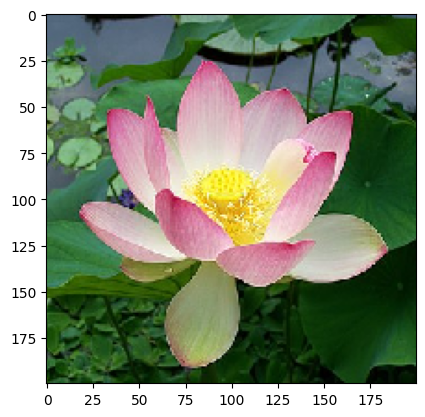

In [32]:
path = "/content/hoasen.png"
img = load_img(path, target_size=(img_width, img_height))
plt.imshow(img)
img = np.array(img)
img = img/255.0
img = img.reshape(1, img_width, img_height, 3)

prediction = np.argmax(model.predict(img))
class_labels = {v:k for k, v in train_generator.class_indices.items()}
dish_name = class_labels[prediction]
print(f"Loại hoa tiên đoán: {dish_name}")